In [1]:
from schrodinger_box.time_independent_1d import PotentialHarmonicOscillator,ansatzfactor_HO_sym
from core.neural_network import FeedForwardNN
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
L = 1.0 # Length of box

In [4]:
from schrodinger_box.tise1d_box import PINN, Loss_PDE, Loss_Norm, Loss_Orthogonality
from core.interfaces import PhysicsLoss,AnsatzFactor,Potential
from torch.utils.data import DataLoader

torch.manual_seed(124)

def train_tise_example(
    loss_func: PhysicsLoss,
    x_lim: tuple[float,float] = (0.0,1.0),
    n_epochs: int = 3000,
    N_samples: int = 256,
    E: float = 0.5,
    hidden_layers: int = 3,
    width: int = 32,
    lambd: float = 0.0,
    lr: float = 1e-2,
    batch_size: int = 64,
    ansatz_factor: "AnsatzFactor | None" = ansatzfactor_HO_sym,
    potential: "Potential | None" = None,
    step_method: str = "Adam", 
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
):

    x = torch.linspace(0,L,N_samples).view(-1, 1).to(device)
    input_loader = DataLoader(x, batch_size=batch_size, shuffle=True)
    device = torch.device(device)

    #Build the model
    model = FeedForwardNN(
        in_dim=1,
        out_dim=1,
        hidden_layers=hidden_layers,
        width=width,
        activation_func=nn.Tanh,
    ).to(device)
    pinn = PINN(model, ansatz_factor,L=L, E = E).to(device)

    # Define optimizer
    
    if step_method == "Adam": 
        optimizer = torch.optim.Adam(pinn.parameters(), lr=lr,weight_decay=lambd)
    elif step_method == "RMSProp": 
        optimizer = torch.optim.RMSprop(pinn.parameters(), lr=lr,weight_decay=lambd)
    else:
        raise ValueError("step_method must be either 'Adam' or 'RMSProp'")

    # Train the model
    for epoch in range(1, n_epochs + 1):

        #x_batch = torch.rand(N_samples, 1, device=device) * 2*L - L
        #input_loader = DataLoader(x_batch, batch_size=batch_size, shuffle=True)

        epoch_loss = torch.Tensor([0.0]).to(device)
        for batch in input_loader: 
            optimizer.zero_grad()
            loss = loss_func(pinn, batch.view(-1, 1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{n_epochs}. Loss={float(epoch_loss.detach()):.3e}...", end="\r")
            # print(f"Individual losses: {total_loss_fn.compute_individual_losses(pinn, x.view(-1,1))}")

    # After training, return model
    return pinn

In [ ]:
from scipy.special import hermite,factorial
import numpy as np

def psi_analytic(x, L = None, n=1):
    hbar = 1
    m = 1
    omega = 1
    x = x.numpy()
    return torch.tensor((1/(np.sqrt((2**n)*np.exp(factorial(n+1)))*np.pi**0.25))*np.exp(-x**2/2)*hermite(n)(x))

def energy_analytic(L=None,n=1):
    hbar = 1
    omega = 1
    return (n + 0.5)

def compare_analytic(x, pinn, n=1):
    with torch.no_grad():
        psi_pred = pinn(x.to(device)).cpu()
    psi_exact = psi_analytic(x,x[-1], n).cpu()

    overlap = torch.sum(psi_pred*psi_exact) 

    if overlap < 0: 
        psi_pred = -psi_pred

    energy_pred =  pinn.E       #torch.sqrt(Loss_PDE()(pinn,x)) 
    energy_exact = energy_analytic(x[-1], n)
    rel_error = torch.abs((energy_pred - energy_exact) / energy_exact)
    print(f"Predicted Energy: {energy_pred.item():.6f}, Exact Energy: {energy_exact:.6f}, Relative Error: {rel_error:.6%}")
    
    
    plt.plot(x.numpy(), psi_pred.numpy()/torch.sqrt((2*(x[-1] - x[0])*torch.mean(psi_pred**2))), label='PINN Prediction')
    plt.plot(x.numpy(), psi_exact.numpy(), label='Analytic Solution', linestyle='dashed')
    plt.xlabel('x')
    plt.ylabel('ψ(x)')
    plt.title('Comparison of PINN and Analytic Solution')
    plt.legend()
    plt.show()

In [6]:
pinn1 = train_tise_example(
    loss_func = Loss_PDE(PotentialHarmonicOscillator()),       #  + 100*Loss_Norm()
    x_lim=[-L,L],
    batch_size = 256,
    lr = 1e-1,
    E = 0.1
)

In [7]:
# Freeze
pinn1.eval()  # freeze behavior
for p in pinn1.parameters():
    p.requires_grad_(False)  

Predicted Energy: 0.500006, Exact Energy: 0.500000, Relative Error: 0.001132%


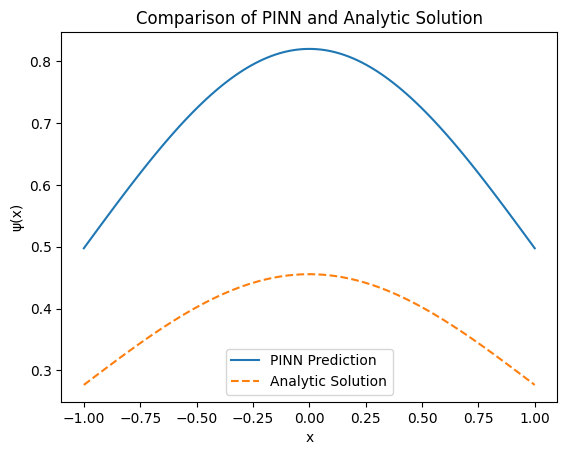

In [8]:
x_test = torch.linspace(-L, L, 100).view(-1, 1).to(device)
compare_analytic(x_test,pinn1,n=0)

In [9]:
pinn2 = train_tise_example(
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 2000*Loss_Orthogonality([pinn1]),     # + 500*Loss_Norm()
    x_lim=[-L,L],
    batch_size = 256,
    lr = 2.5e-2,
    E = 0.5
)

In [10]:
# Freeze
pinn2.eval()  # freeze behavior
for p in pinn2.parameters():
    p.requires_grad_(False)

Predicted Energy: 4.814922, Exact Energy: 1.500000, Relative Error: 220.994782%


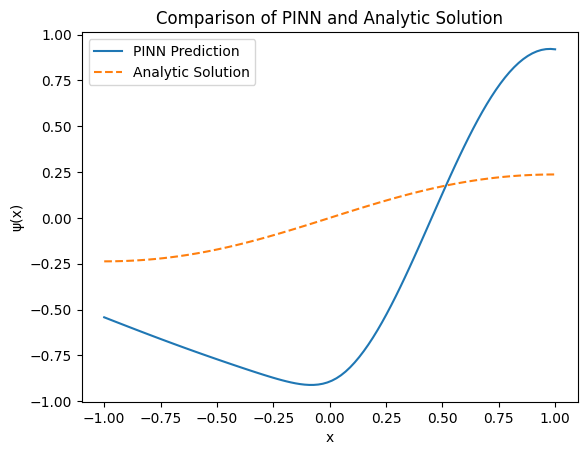

In [11]:
x_test = torch.linspace(-L, L, 100).view(-1, 1).to(device)
compare_analytic(x_test, pinn2,n=1)